In [1]:
import pandas as pd
import numpy as np

In [2]:
#Load Dataset
df = pd.read_csv("Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

In [5]:
#Check for null values
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [6]:
#Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [7]:
#Remove unwanted columns
df1 = df.drop("Id",axis='columns').reset_index(drop=True).copy()

In [8]:
df1.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
#Assign Features and output to different variables
X = df1[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]
y = df1['Species']

In [10]:
#Did Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
#Import necessary models from sklearn module
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [12]:
Model_Param = {
    'logistic_regression': {
        'model': LogisticRegression(solver='liblinear'),
        'params': {
            'C':[0.01,0.1,1,10]
        }
    },
    'Random_Forest': {
        'model':RandomForestClassifier(),
        'params':{
            'n_estimators':[10,50,100]
        }
    }
}

In [13]:
#Use Grid Search CV to find the Best model with Best parameters
scores = []
for model_name,mp in Model_Param.items():
    clf = GridSearchCV(mp['model'],mp['params'],cv=5,return_train_score=False)
    clf.fit(X_train,y_train)
    scores.append({
    'model':model_name,
    'best_score':clf.best_score_,
    'best_params':clf.best_params_
    })

In [14]:
model_selection = pd.DataFrame(scores,columns=['model','best_score','best_params'])
model_selection

,model,best_score,best_params
0,logistic_regression,0.958333,{'C': 10}
1,Random_Forest,0.950000,{'n_estimators': 50}


In [15]:
#Finalise Logistic Regression model to use for classification(Train Model)
model = LogisticRegression(solver='liblinear',C=10)
model.fit(X_train,y_train)

LogisticRegression(C=10, solver='liblinear')

In [16]:
y_pred = model.predict(X_test)

In [17]:
y_pred

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa'], dtype=object)

In [18]:
model.score(X_test,y_test)

1.0

In [19]:
#Print classification report
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



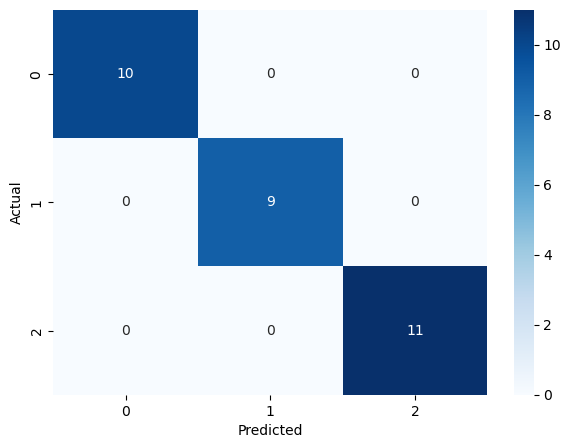

In [20]:
#Visualisation using heatmap
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sn
plt.figure(figsize=(7,5))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [21]:
import joblib
joblib.dump(model, "iris_model.pkl")

['iris_model.pkl']